In [ ]:
!kaggle datasets download akashshingha850/mrl-eye-dataset
!unzip /content/mrl-eye-dataset.zip

In [2]:
import tensorflow
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

In [3]:
# Training Generator: Has realistic data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=(0.8, 1.2),
    zoom_range=(0.9, 1.1),
    horizontal_flip=True

)

# Validation Generator: Strictly rescales, NO augmentations!
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Re-link the directory iterators
train_directory_interator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(64,64),
    batch_size=32,
    color_mode='grayscale',
    class_mode='binary',
)

val_directory_interator = val_datagen.flow_from_directory(
    'data/test',
    target_size=(64,64),
    batch_size=32,
    color_mode='grayscale',
    class_mode='binary',
)

Found 50937 images belonging to 2 classes.
Found 16981 images belonging to 2 classes.


In [4]:
from tensorflow.keras.models import Sequential

In [ ]:
model = Sequential()

model.add(Conv2D(16, (3,3), padding='valid', activation='relu', input_shape=(64,64,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(padding='valid', strides=2))

model.add(Conv2D(32, (3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(padding='valid', strides=2))

model.add(Conv2D(64, (3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(padding='valid', strides=2))

model.add(Flatten())

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

c:\Users\deves\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 31, 31, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        73,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,049 (383.00 KB)

 Trainable params: 97,825 (382.13 KB)

 Non-trainable params: 224 (896.00 B)

In [6]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:


history = model.fit(
    train_directory_interator,
    epochs=5,
    validation_data=val_directory_interator
)

Epoch 1/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 124s 76ms/step - accuracy: 0.8704 - loss: 0.3140 - val_accuracy: 0.9635 - val_loss: 0.1151
Epoch 2/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 85s 53ms/step - accuracy: 0.9468 - loss: 0.1556 - val_accuracy: 0.9782 - val_loss: 0.0599
Epoch 3/10
1291/1592 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.9602 - loss: 0.1147

KeyboardInterrupt: 

In [12]:
import matplotlib.pyplot as plt


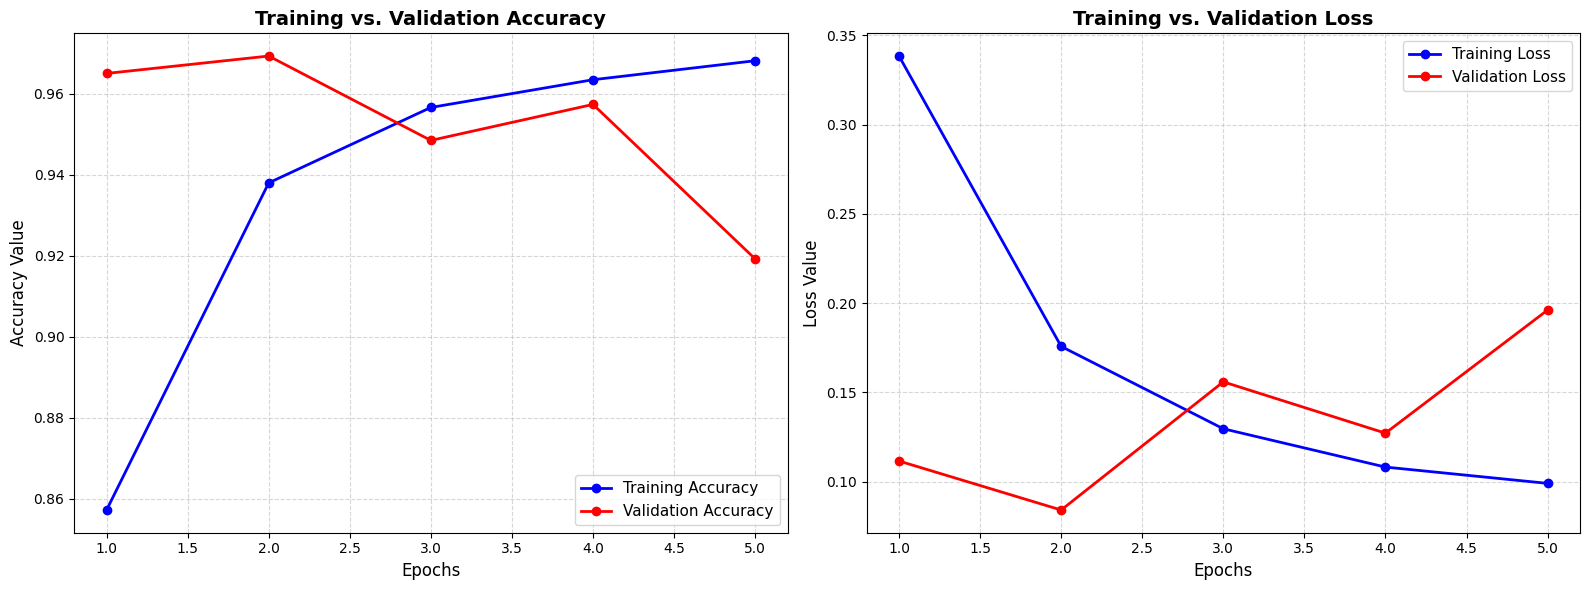

In [14]:
history_dict = history.history
accuracy_values = history_dict['accuracy']
val_accuracy_values = history_dict['val_accuracy']
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(accuracy_values) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epochs, accuracy_values, 'bo-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs, val_accuracy_values, 'ro-', label='Validation Accuracy', linewidth=2)
ax1.set_title('Training vs. Validation Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy Value', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(epochs, loss_values, 'bo-', label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss_values, 'ro-', label='Validation Loss', linewidth=2)
ax2.set_title('Training vs. Validation Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss Value', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

In [16]:
model.save('model.h5')